## Step 1: Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/home/claude/blood_donor_dataset.csv')
print(df.shape)
print(df.head())

(500, 14)
   donor_id     name            email password  contact_number  created_at  \
0         1  Donor_0  donor0@mail.com  pass123      9534895718  2020-01-01   
1         2  Donor_1  donor1@mail.com  pass123      9199900595  2020-01-02   
2         3  Donor_2  donor2@mail.com  pass123      9862061404  2020-01-03   
3         4  Donor_3  donor3@mail.com  pass123      9787846414  2020-01-04   
4         5  Donor_4  donor4@mail.com  pass123      9996406378  2020-01-05   

   age  weight       city blood_group  last_donation_days  donations_count  \
0   59      50       Pune         AB+                 343                7   
1   43      50  Bangalore          A-                 309               17   
2   52      99    Chennai          O+                  88                8   
3   42      92     Mumbai          B+                 212                7   
4   41      48      Delhi         AB-                 142               13   

   haemoglobin availability  
0         13.9        

## Step 2: Preprocessing

In [2]:
print(df.isnull().sum())

donor_id              0
name                  0
email                 0
password              0
contact_number        0
created_at            0
age                   0
weight                0
city                  0
blood_group           0
last_donation_days    0
donations_count       0
haemoglobin           0
availability          0
dtype: int64


In [3]:
print(df.dtypes)

donor_id                int64
name                      str
email                     str
password                  str
contact_number          int64
created_at                str
age                     int64
weight                  int64
city                      str
blood_group               str
last_donation_days      int64
donations_count         int64
haemoglobin           float64
availability              str
dtype: object


In [4]:
# Drop irrelevant columns
df = df.drop(columns=['donor_id','name','email','password','contact_number','created_at'])
print(df.head())

   age  weight       city blood_group  last_donation_days  donations_count  \
0   59      50       Pune         AB+                 343                7   
1   43      50  Bangalore          A-                 309               17   
2   52      99    Chennai          O+                  88                8   
3   42      92     Mumbai          B+                 212                7   
4   41      48      Delhi         AB-                 142               13   

   haemoglobin availability  
0         13.9           No  
1         13.2           No  
2         12.4           No  
3         13.3          Yes  
4         15.8          Yes  


In [5]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
le = LabelEncoder()
df['blood_group'] = le.fit_transform(df['blood_group'])
df['availability'] = le.fit_transform(df['availability'])  # Yes=1, No=0
# Use pd.get_dummies for 'city' to avoid false ordinal relationship
df = pd.get_dummies(df, columns=['city'], drop_first=True)
# Convert boolean dummies to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.head())
print(df['availability'].value_counts())


   age  weight  blood_group  last_donation_days  donations_count  haemoglobin  \
0   59      50            2                 343                7         13.9   
1   43      50            1                 309               17         13.2   
2   52      99            6                  88                8         12.4   
3   42      92            4                 212                7         13.3   
4   41      48            3                 142               13         15.8   

   availability  city_Chennai  city_Delhi  city_Hyderabad  city_Kolkata  \
0             0             0           0               0             0   
1             0             0           0               0             0   
2             0             1           0               0             0   
3             1             0           0               0             0   
4             1             0           1               0             0   

   city_Mumbai  city_Pune  
0            0          1  
1     

## Step 3: Features & Target

In [6]:
x = df.drop('availability', axis=1)
y = df['availability']
print('Features:', x.columns.tolist())
print('Target distribution:\n', y.value_counts())

Features: ['age', 'weight', 'blood_group', 'last_donation_days', 'donations_count', 'haemoglobin', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai', 'city_Pune']
Target distribution:
 availability
0    322
1    178
Name: count, dtype: int64


## Step 4: Check Balance BEFORE SMOTE

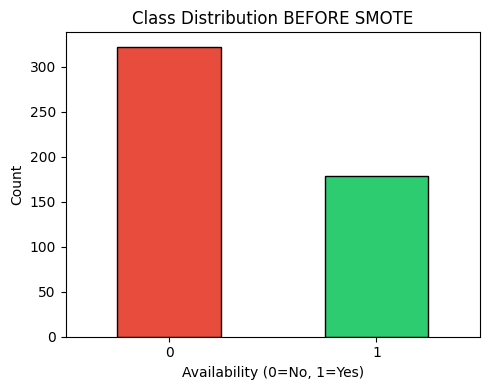

In [7]:
plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Class Distribution BEFORE SMOTE')
plt.xlabel('Availability (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: Train-Test Split + Normalization

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20, stratify=y)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print('Train size:', x_train.shape)
print('Test size :', x_test.shape)
print('Before SMOTE - y_train distribution:\n', pd.Series(y_train).value_counts())

Train size: (400, 12)
Test size : (100, 12)
Before SMOTE - y_train distribution:
 availability
0    258
1    142
Name: count, dtype: int64


---
## BEFORE SMOTE — Model Results

### Logistic Regression (Before SMOTE)

Accuracy: 0.63
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.92      0.76        64
           1       0.44      0.11      0.18        36

    accuracy                           0.63       100
   macro avg       0.55      0.52      0.47       100
weighted avg       0.57      0.63      0.55       100



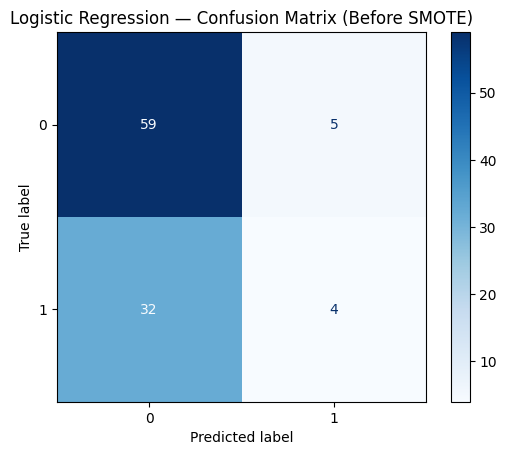

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

acc_lr_before = accuracy_score(y_test, y_pred_lr)
print('Accuracy:', acc_lr_before)
print('Classification Report:\n', classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix (Before SMOTE)')
plt.show()

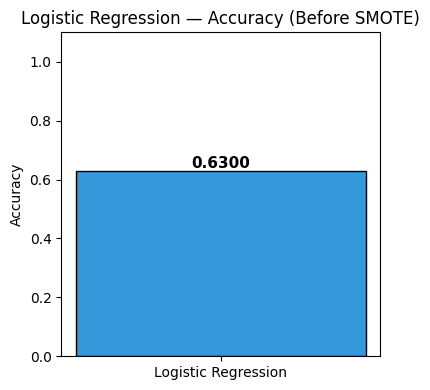

In [10]:
plt.figure(figsize=(4,4))
plt.bar(['Logistic Regression'], [acc_lr_before], color='#3498db', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_lr_before]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Logistic Regression — Accuracy (Before SMOTE)')
plt.tight_layout()
plt.show()


### SVM — Default RBF (Before SMOTE)

Accuracy: 0.62


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.94      0.76        64
           1       0.33      0.06      0.10        36

    accuracy                           0.62       100
   macro avg       0.49      0.50      0.43       100
weighted avg       0.53      0.62      0.52       100



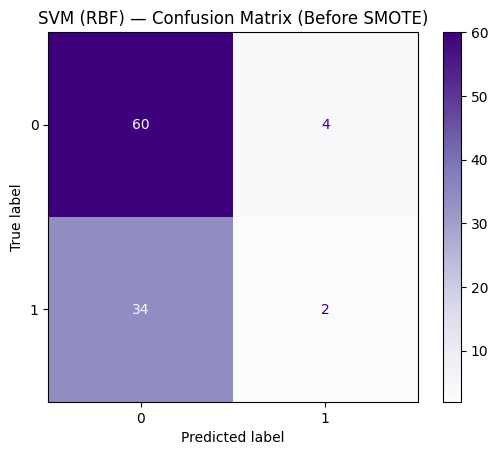

In [11]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

acc_svm_before = accuracy_score(y_test, y_pred_svm)
print('Accuracy:', acc_svm_before)
print('Classification Report:\n', classification_report(y_test, y_pred_svm))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot(cmap='Purples')
plt.title('SVM (RBF) — Confusion Matrix (Before SMOTE)')
plt.show()

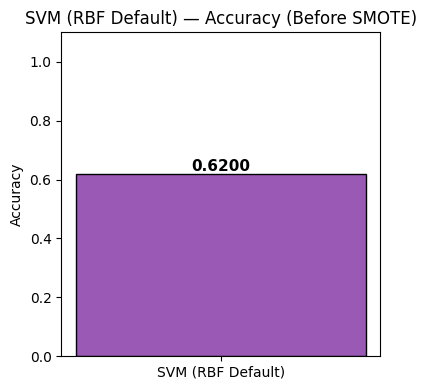

In [12]:
plt.figure(figsize=(4,4))
plt.bar(['SVM (RBF Default)'], [acc_svm_before], color='#9b59b6', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_svm_before]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('SVM (RBF Default) — Accuracy (Before SMOTE)')
plt.tight_layout()
plt.show()


### SVM — 3 Kernels (Before SMOTE)

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kernels = ['linear', 'poly', 'rbf']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
before_scores = []

for kernel in kernels:
    model = SVC(kernel=kernel)
    scores = cross_val_score(model, x, y, cv=skf)
    before_scores.append(scores.mean())
    print(f'SVM {kernel} CV Accuracy (Before SMOTE): {scores.mean():.4f}')


SVM linear CV Accuracy (Before SMOTE): 0.6440
SVM poly CV Accuracy (Before SMOTE): 0.6440
SVM rbf CV Accuracy (Before SMOTE): 0.6440


SVM Linear Accuracy: 0.64
              precision    recall  f1-score   support

           0       0.64      1.00      0.78        64
           1       0.00      0.00      0.00        36

    accuracy                           0.64       100
   macro avg       0.32      0.50      0.39       100
weighted avg       0.41      0.64      0.50       100



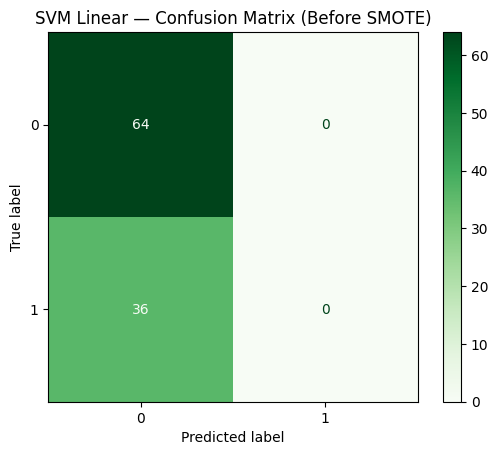

SVM Poly Accuracy: 0.65
              precision    recall  f1-score   support

           0       0.65      0.97      0.78        64
           1       0.60      0.08      0.15        36

    accuracy                           0.65       100
   macro avg       0.63      0.53      0.46       100
weighted avg       0.63      0.65      0.55       100



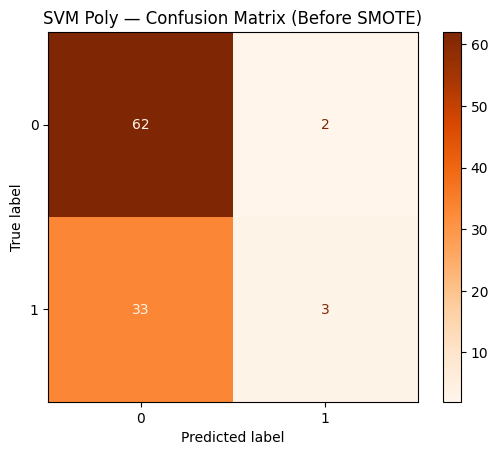

SVM RBF Accuracy: 0.62
              precision    recall  f1-score   support

           0       0.64      0.94      0.76        64
           1       0.33      0.06      0.10        36

    accuracy                           0.62       100
   macro avg       0.49      0.50      0.43       100
weighted avg       0.53      0.62      0.52       100



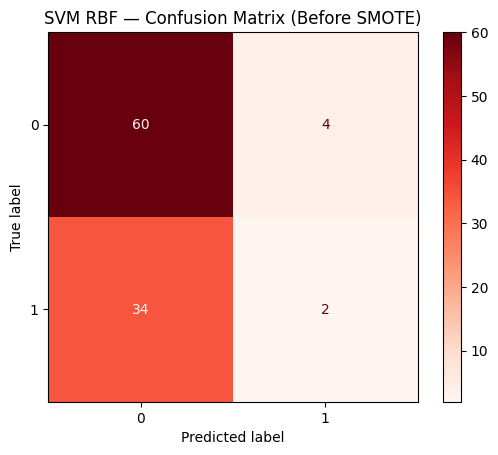

In [14]:
# SVM Linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(x_train, y_train)
y_pred_linear = svm_linear.predict(x_test)
acc_linear_before = accuracy_score(y_test, y_pred_linear)
print('SVM Linear Accuracy:', acc_linear_before)
print(classification_report(y_test, y_pred_linear))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_linear)).plot(cmap='Greens')
plt.title('SVM Linear — Confusion Matrix (Before SMOTE)')
plt.show()

# SVM Poly
svm_poly = SVC(kernel='poly')
svm_poly.fit(x_train, y_train)
y_pred_poly = svm_poly.predict(x_test)
acc_poly_before = accuracy_score(y_test, y_pred_poly)
print('SVM Poly Accuracy:', acc_poly_before)
print(classification_report(y_test, y_pred_poly))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_poly)).plot(cmap='Oranges')
plt.title('SVM Poly — Confusion Matrix (Before SMOTE)')
plt.show()

# SVM RBF
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(x_train, y_train)
y_pred_rbf = svm_rbf.predict(x_test)
acc_rbf_before = accuracy_score(y_test, y_pred_rbf)
print('SVM RBF Accuracy:', acc_rbf_before)
print(classification_report(y_test, y_pred_rbf))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rbf)).plot(cmap='Reds')
plt.title('SVM RBF — Confusion Matrix (Before SMOTE)')
plt.show()

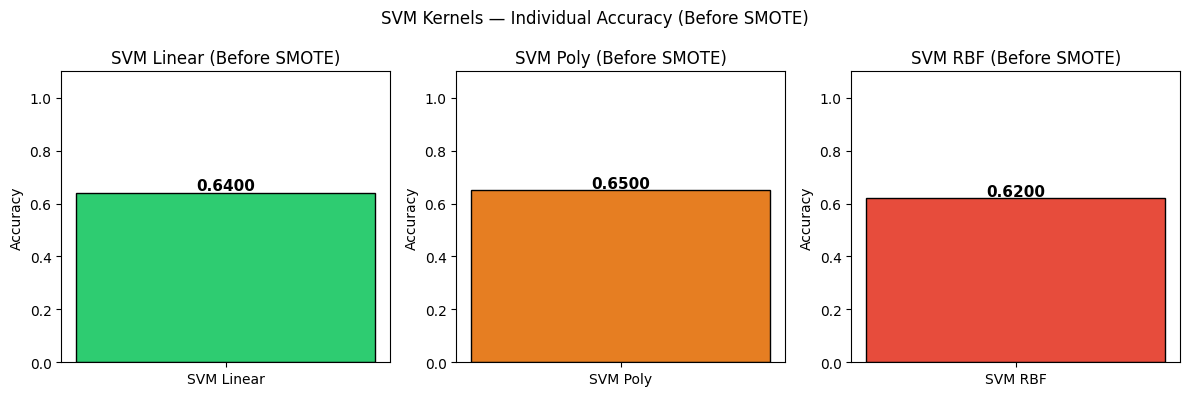

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, (label, acc, color) in zip(axes, [
    ('SVM Linear', acc_linear_before, '#2ecc71'),
    ('SVM Poly',   acc_poly_before,   '#e67e22'),
    ('SVM RBF',    acc_rbf_before,    '#e74c3c')
]):
    ax.bar([label], [acc], color=color, edgecolor='black')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.text(0, acc + 0.01, f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{label} (Before SMOTE)')
plt.suptitle('SVM Kernels — Individual Accuracy (Before SMOTE)')
plt.tight_layout()
plt.show()


### Before SMOTE — All Model Results + Plot

===== BEFORE SMOTE =====
Logistic Regression Accuracy: 0.63
SVM (default) Accuracy : 0.62
SVM Linear Accuracy : 0.64
SVM Poly Accuracy : 0.65
SVM RBF Accuracy : 0.62


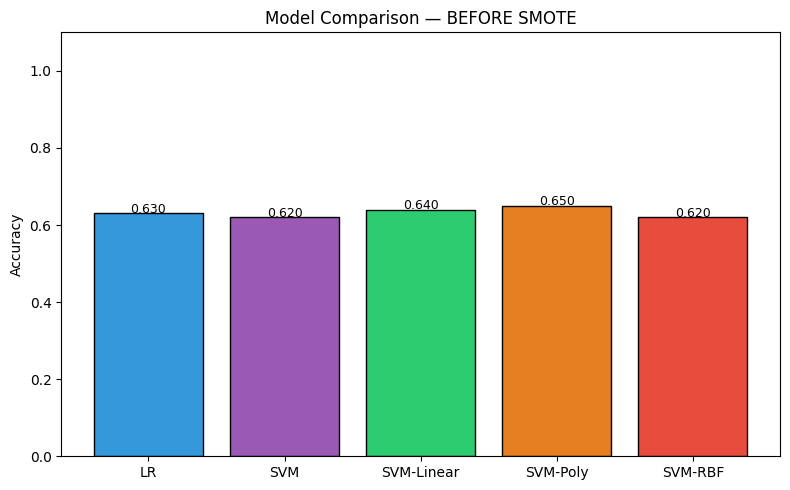

In [16]:
print('===== BEFORE SMOTE =====')
print('Logistic Regression Accuracy:', acc_lr_before)
print('SVM (default) Accuracy :', acc_svm_before)
print('SVM Linear Accuracy :', acc_linear_before)
print('SVM Poly Accuracy :', acc_poly_before)
print('SVM RBF Accuracy :', acc_rbf_before)

labels_before = ['LR','SVM','SVM-Linear','SVM-Poly','SVM-RBF']
accs_before = [acc_lr_before, acc_svm_before, acc_linear_before, acc_poly_before, acc_rbf_before]

plt.figure(figsize=(8,5))
bars = plt.bar(labels_before, accs_before, color=['#3498db','#9b59b6','#2ecc71','#e67e22','#e74c3c'], edgecolor='black')
for bar, acc in zip(bars, accs_before):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{acc:.3f}', ha='center', fontsize=9)
plt.ylim(0, 1.1)
plt.title('Model Comparison — BEFORE SMOTE')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


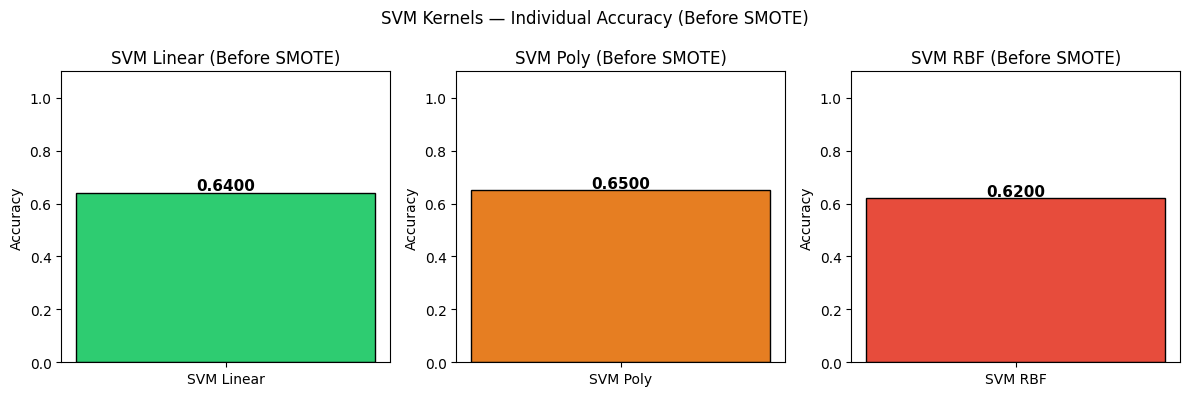

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, (label, acc, color) in zip(axes, [
    ('SVM Linear', acc_linear_before, '#2ecc71'),
    ('SVM Poly',   acc_poly_before,   '#e67e22'),
    ('SVM RBF',    acc_rbf_before,    '#e74c3c')
]):
    ax.bar([label], [acc], color=color, edgecolor='black')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.text(0, acc + 0.01, f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{label} (Before SMOTE)')
plt.suptitle('SVM Kernels — Individual Accuracy (Before SMOTE)')
plt.tight_layout()
plt.show()


### SVM Kernel Boxplot (Before SMOTE)

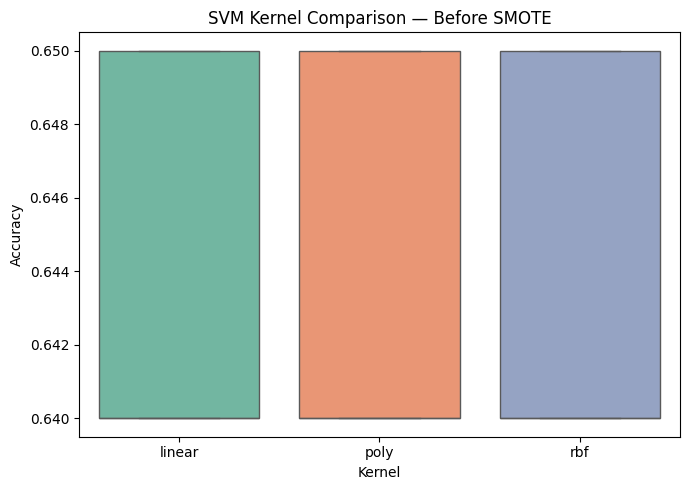

In [18]:
data_before = []
for kernel in kernels:
    model = SVC(kernel=kernel)
    scores = cross_val_score(model, x, y, cv=skf)
    for score in scores:
        data_before.append([kernel, score, 'Before SMOTE'])
df_before_box = pd.DataFrame(data_before, columns=['Kernel','Accuracy','Type'])

plt.figure(figsize=(7,5))
sns.boxplot(x='Kernel', y='Accuracy', data=df_before_box, palette='Set2')
plt.title('SVM Kernel Comparison — Before SMOTE')
plt.tight_layout()
plt.show()


---
## SMOTE — Balancing

Before SMOTE: {0: 258, 1: 142}
After SMOTE : {0: 258, 1: 258}


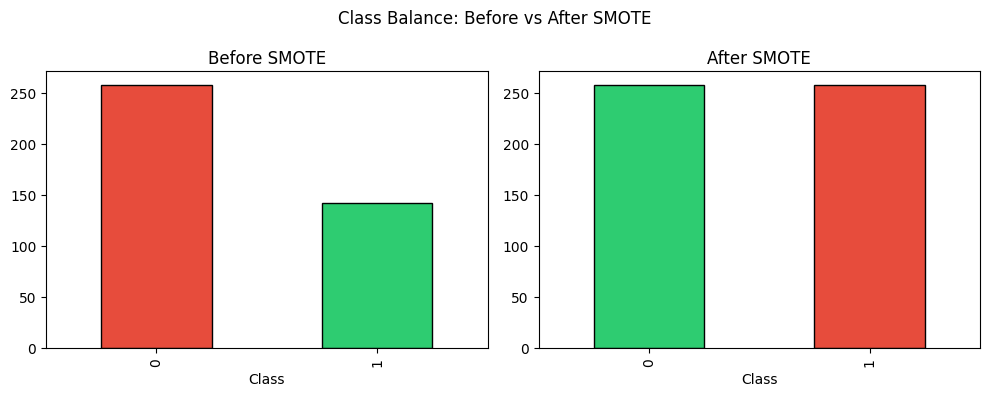

In [19]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=20)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print('After SMOTE :', pd.Series(y_train_sm).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10,4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
plt.suptitle('Class Balance: Before vs After SMOTE')
plt.tight_layout()
plt.show()

---
## AFTER SMOTE — Model Results

### Logistic Regression (After SMOTE)

Accuracy: 0.51
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.65      0.52      0.57        64
           1       0.37      0.50      0.42        36

    accuracy                           0.51       100
   macro avg       0.51      0.51      0.50       100
weighted avg       0.55      0.51      0.52       100



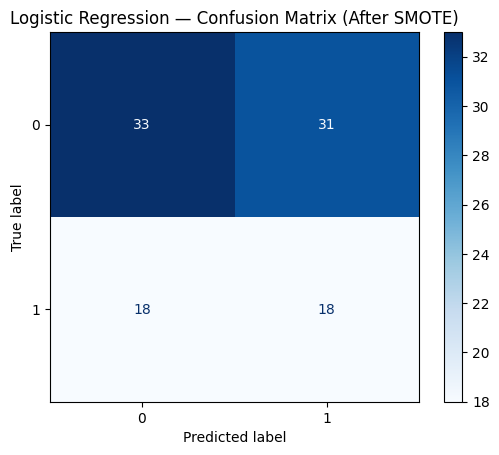

In [20]:
lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(x_train_sm, y_train_sm)
y_pred_lr_sm = lr_sm.predict(x_test)

acc_lr_after = accuracy_score(y_test, y_pred_lr_sm)
print('Accuracy:', acc_lr_after)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_lr_sm))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr_sm)).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix (After SMOTE)')
plt.show()

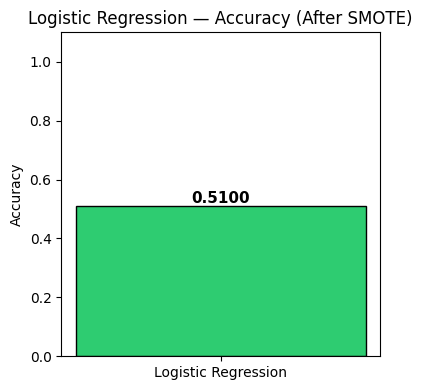

In [21]:
plt.figure(figsize=(4,4))
plt.bar(['Logistic Regression'], [acc_lr_after], color='#2ecc71', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_lr_after]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Logistic Regression — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


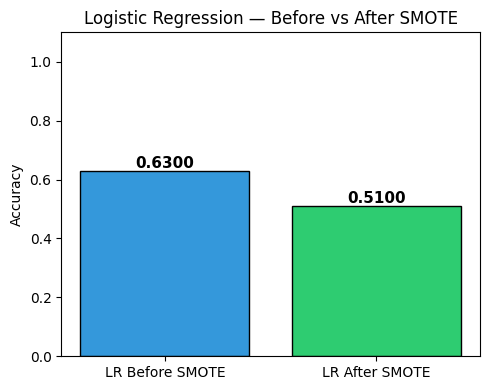

In [22]:
# LR Before vs After SMOTE
plt.figure(figsize=(5,4))
bars = plt.bar(['LR Before SMOTE','LR After SMOTE'], [acc_lr_before, acc_lr_after],
               color=['#3498db','#2ecc71'], edgecolor='black')
for bar, v in zip(bars, [acc_lr_before, acc_lr_after]):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Logistic Regression — Before vs After SMOTE')
plt.tight_layout()
plt.show()


### SVM — 3 Kernels (After SMOTE)

In [23]:
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
after_scores = []
for kernel in kernels:
    model = SVC(kernel=kernel)
    scores = cross_val_score(model, x_train_sm, y_train_sm, cv=skf2)
    after_scores.append(scores.mean())
    print(f'SVM {kernel} CV Accuracy (After SMOTE): {scores.mean():.4f}')


SVM linear CV Accuracy (After SMOTE): 0.5524
SVM poly CV Accuracy (After SMOTE): 0.5835
SVM rbf CV Accuracy (After SMOTE): 0.5950


SVM Linear Accuracy (After SMOTE): 0.51
              precision    recall  f1-score   support

           0       0.66      0.48      0.56        64
           1       0.38      0.56      0.45        36

    accuracy                           0.51       100
   macro avg       0.52      0.52      0.50       100
weighted avg       0.56      0.51      0.52       100



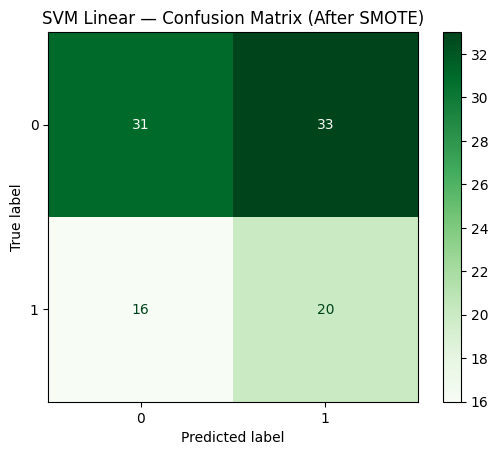

SVM Poly Accuracy (After SMOTE): 0.6
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        64
           1       0.43      0.36      0.39        36

    accuracy                           0.60       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.59      0.60      0.59       100



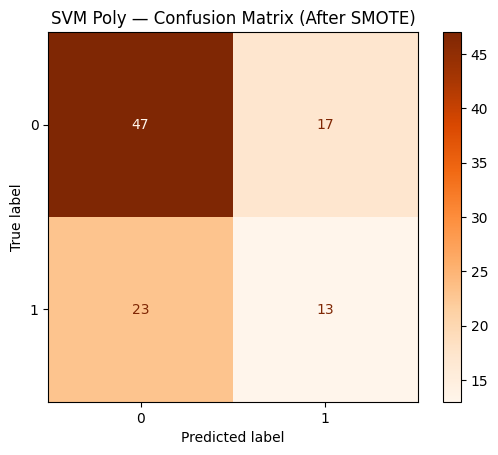

SVM RBF Accuracy (After SMOTE): 0.59
              precision    recall  f1-score   support

           0       0.68      0.69      0.68        64
           1       0.43      0.42      0.42        36

    accuracy                           0.59       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.59      0.59      0.59       100



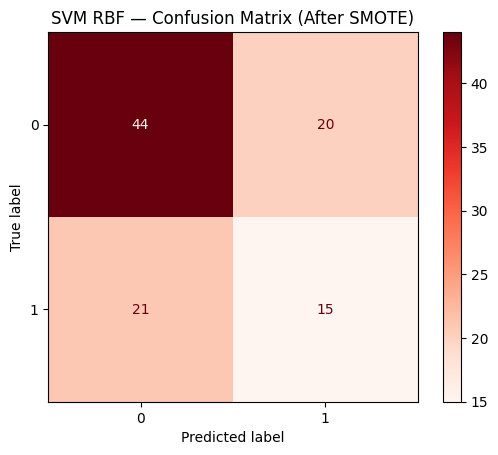

In [24]:
# SVM Linear After SMOTE
svm_lin_sm = SVC(kernel='linear')
svm_lin_sm.fit(x_train_sm, y_train_sm)
y_pred_lin_sm = svm_lin_sm.predict(x_test)
acc_linear_after = accuracy_score(y_test, y_pred_lin_sm)
print('SVM Linear Accuracy (After SMOTE):', acc_linear_after)
print(classification_report(y_test, y_pred_lin_sm))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lin_sm)).plot(cmap='Greens')
plt.title('SVM Linear — Confusion Matrix (After SMOTE)')
plt.show()

# SVM Poly After SMOTE
svm_poly_sm = SVC(kernel='poly')
svm_poly_sm.fit(x_train_sm, y_train_sm)
y_pred_poly_sm = svm_poly_sm.predict(x_test)
acc_poly_after = accuracy_score(y_test, y_pred_poly_sm)
print('SVM Poly Accuracy (After SMOTE):', acc_poly_after)
print(classification_report(y_test, y_pred_poly_sm))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_poly_sm)).plot(cmap='Oranges')
plt.title('SVM Poly — Confusion Matrix (After SMOTE)')
plt.show()

# SVM RBF After SMOTE
svm_rbf_sm = SVC(kernel='rbf')
svm_rbf_sm.fit(x_train_sm, y_train_sm)
y_pred_rbf_sm = svm_rbf_sm.predict(x_test)
acc_rbf_after = accuracy_score(y_test, y_pred_rbf_sm)
print('SVM RBF Accuracy (After SMOTE):', acc_rbf_after)
print(classification_report(y_test, y_pred_rbf_sm))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rbf_sm)).plot(cmap='Reds')
plt.title('SVM RBF — Confusion Matrix (After SMOTE)')
plt.show()

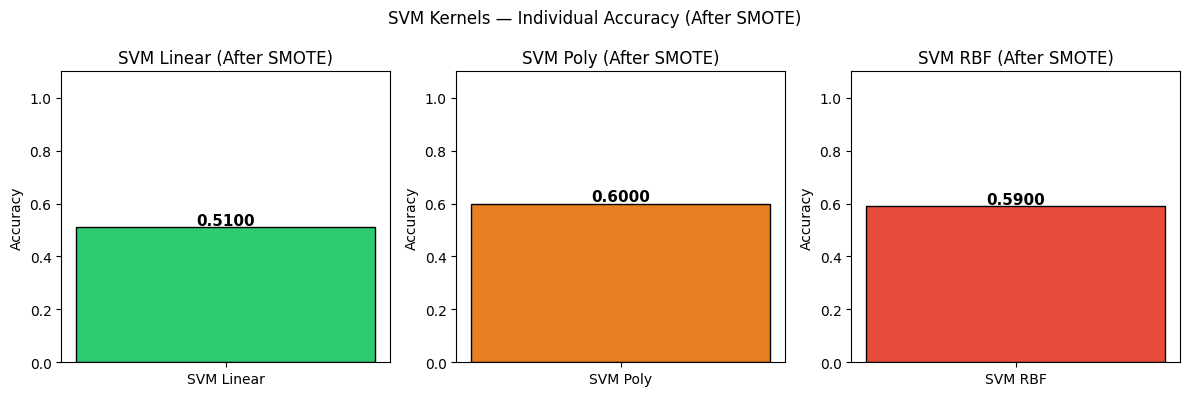

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, (label, acc, color) in zip(axes, [
    ('SVM Linear', acc_linear_after, '#2ecc71'),
    ('SVM Poly',   acc_poly_after,   '#e67e22'),
    ('SVM RBF',    acc_rbf_after,    '#e74c3c')
]):
    ax.bar([label], [acc], color=color, edgecolor='black')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy')
    ax.text(0, acc + 0.01, f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{label} (After SMOTE)')
plt.suptitle('SVM Kernels — Individual Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


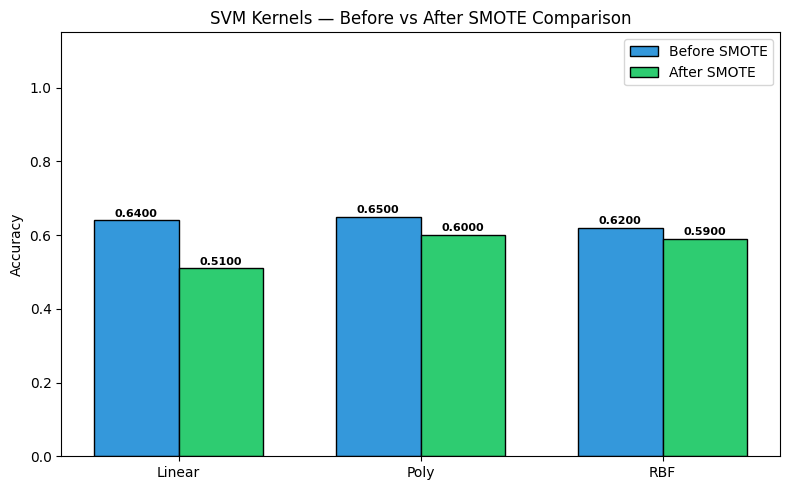

In [26]:
# SVM All Kernels Before vs After SMOTE — grouped bar
kernels_labels = ['Linear', 'Poly', 'RBF']
before_vals = [acc_linear_before, acc_poly_before, acc_rbf_before]
after_vals  = [acc_linear_after,  acc_poly_after,  acc_rbf_after]
x_pos = np.arange(len(kernels_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x_pos - width/2, before_vals, width, label='Before SMOTE', color='#3498db', edgecolor='black')
b2 = ax.bar(x_pos + width/2, after_vals,  width, label='After SMOTE',  color='#2ecc71', edgecolor='black')
for bar in b1 + b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(kernels_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('SVM Kernels — Before vs After SMOTE Comparison')
ax.legend()
plt.tight_layout()
plt.show()


### Before vs After SMOTE Comparison Plot

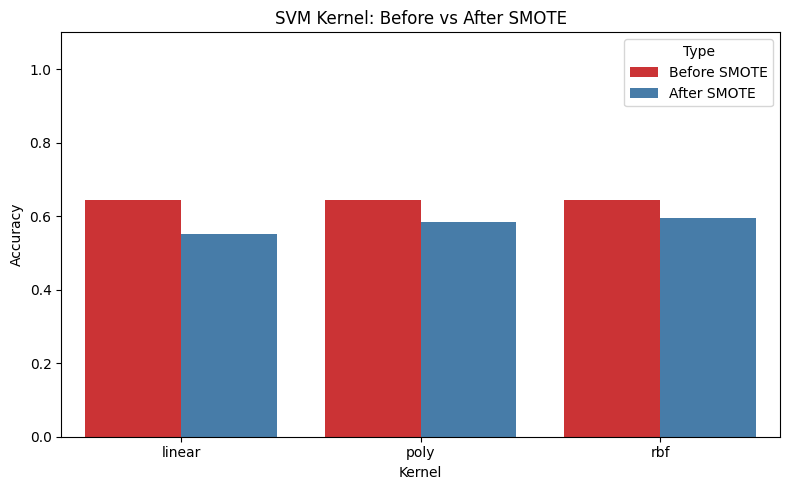

In [27]:
df_b = pd.DataFrame({'Kernel': kernels, 'Accuracy': before_scores, 'Type': 'Before SMOTE'})
df_a = pd.DataFrame({'Kernel': kernels, 'Accuracy': after_scores, 'Type': 'After SMOTE'})
final_df = pd.concat([df_b, df_a])

plt.figure(figsize=(8,5))
sns.barplot(x='Kernel', y='Accuracy', hue='Type', data=final_df, palette='Set1')
plt.title('SVM Kernel: Before vs After SMOTE')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## KNN — Best K

Best K: 2 | Accuracy: 0.63


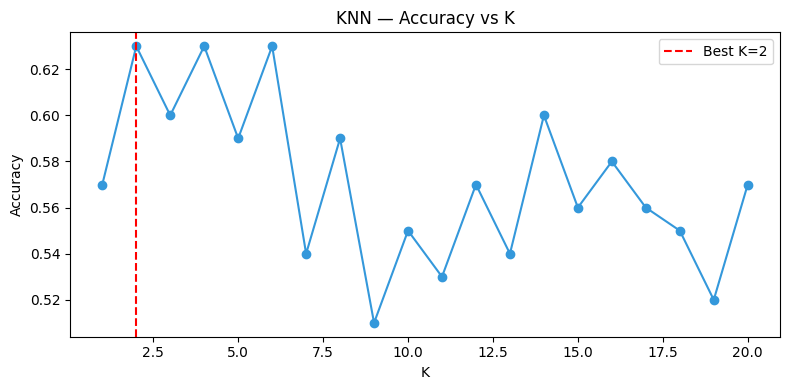

In [28]:
from sklearn.neighbors import KNeighborsClassifier

best_k, best_acc_knn = 0, 0
k_accs = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_sm, y_train_sm)
    pred = knn.predict(x_test)
    acc = accuracy_score(y_test, pred)
    k_accs.append(acc)
    if acc > best_acc_knn:
        best_acc_knn = acc
        best_k = k

print('Best K:', best_k, '| Accuracy:', best_acc_knn)

plt.figure(figsize=(8,4))
plt.plot(range(1,21), k_accs, marker='o', color='#3498db')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN — Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


KNN Best Accuracy: 0.63
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.68      0.78      0.73        64
           1       0.48      0.36      0.41        36

    accuracy                           0.63       100
   macro avg       0.58      0.57      0.57       100
weighted avg       0.61      0.63      0.62       100



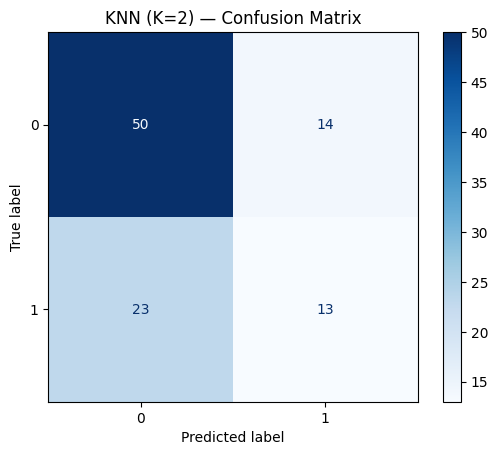

In [29]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(x_train_sm, y_train_sm)
y_pred_knn = knn_best.predict(x_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print('KNN Best Accuracy:', acc_knn)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot(cmap='Blues')
plt.title(f'KNN (K={best_k}) — Confusion Matrix')
plt.show()

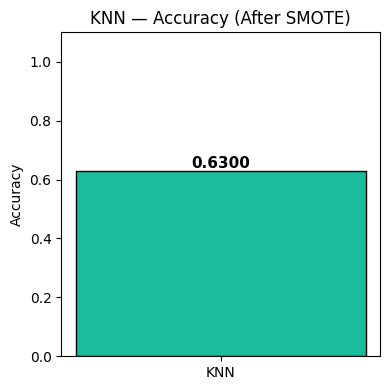

In [30]:
plt.figure(figsize=(4,4))
plt.bar(['KNN'], [acc_knn], color='#1abc9c', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_knn]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('KNN — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


---
## Decision Tree

Decision Tree Accuracy: 0.5
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.61      0.61      0.61        64
           1       0.31      0.31      0.31        36

    accuracy                           0.50       100
   macro avg       0.46      0.46      0.46       100
weighted avg       0.50      0.50      0.50       100



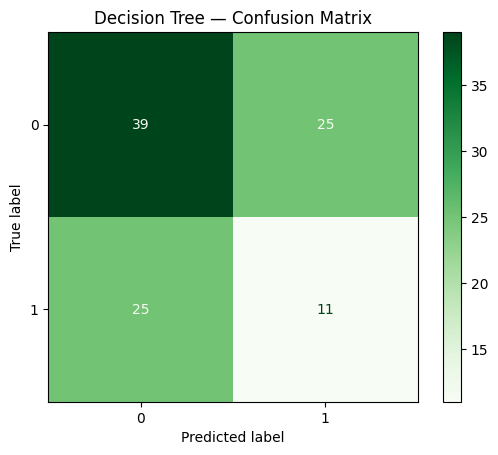

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_sm, y_train_sm)
y_pred_dt = dt.predict(x_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy:', acc_dt)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot(cmap='Greens')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

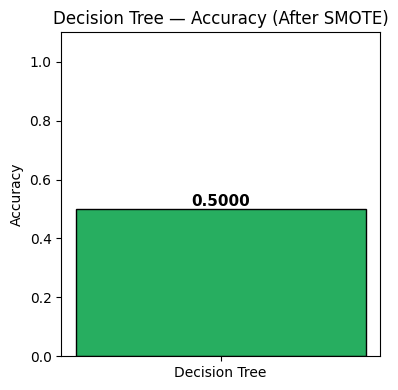

In [32]:
plt.figure(figsize=(4,4))
plt.bar(['Decision Tree'], [acc_dt], color='#27ae60', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_dt]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Decision Tree — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


---
## Hyperparameter Tuning — Random Search & Grid Search (SVM)

In [33]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_dist = {'C':[0.1,1,10,100], 'kernel':['linear','rbf','poly'], 'gamma':['scale','auto']}
random_search = RandomizedSearchCV(SVC(), param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(x_train_sm, y_train_sm)
print('Best Params (Random Search):', random_search.best_params_)
print('Best Score :', random_search.best_score_)

Best Params (Random Search): {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
Best Score : 0.689880507841673


In [34]:
param_grid = {'C':[0.1,1,10], 'kernel':['linear','rbf'], 'gamma':['scale','auto']}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(x_train_sm, y_train_sm)
print('Best Params (Grid Search):', grid_search.best_params_)
print('Best Score :', grid_search.best_score_)

Best Params (Grid Search): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.689880507841673


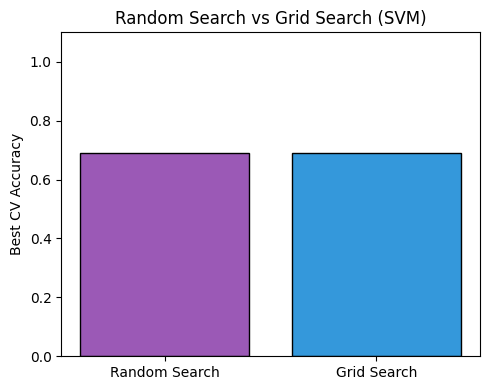

In [35]:
plt.figure(figsize=(5,4))
plt.bar(['Random Search','Grid Search'],[random_search.best_score_, grid_search.best_score_],
color=['#9b59b6','#3498db'], edgecolor='black')
plt.title('Random Search vs Grid Search (SVM)')
plt.ylabel('Best CV Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## Random Forest (Bagging)

Random Forest Accuracy: 0.61
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.69      0.72      0.70        64
           1       0.45      0.42      0.43        36

    accuracy                           0.61       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.60      0.61      0.61       100



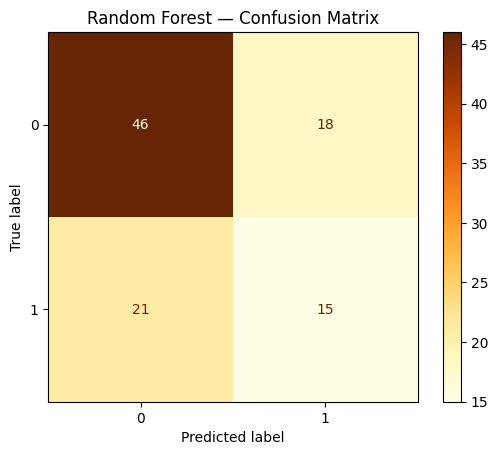

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_sm, y_train_sm)
y_pred_rf = rf.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', acc_rf)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(cmap='YlOrBr')
plt.title('Random Forest — Confusion Matrix')
plt.show()

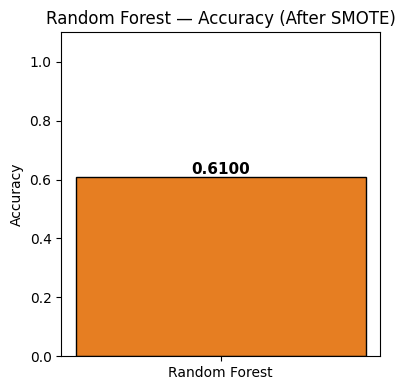

In [37]:
plt.figure(figsize=(4,4))
plt.bar(['Random Forest'], [acc_rf], color='#e67e22', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_rf]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Random Forest — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


---
## Boosting Techniques

### AdaBoost

AdaBoost Accuracy: 0.56
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.66      0.66      0.66        64
           1       0.39      0.39      0.39        36

    accuracy                           0.56       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.56      0.56      0.56       100



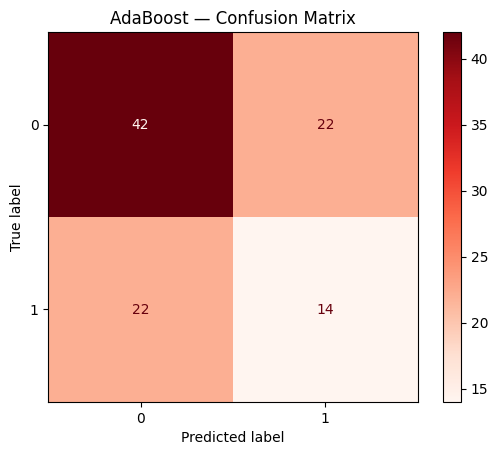

In [38]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(x_train_sm, y_train_sm)
y_pred_ada = ada.predict(x_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
print('AdaBoost Accuracy:', acc_ada)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_ada))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ada)).plot(cmap='Reds')
plt.title('AdaBoost — Confusion Matrix')
plt.show()

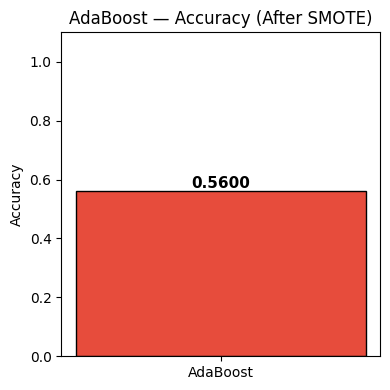

In [39]:
plt.figure(figsize=(4,4))
plt.bar(['AdaBoost'], [acc_ada], color='#e74c3c', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_ada]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('AdaBoost — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


### Gradient Boosting

Gradient Boosting Accuracy: 0.6
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.69      0.67      0.68        64
           1       0.45      0.47      0.46        36

    accuracy                           0.60       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.60      0.60      0.60       100



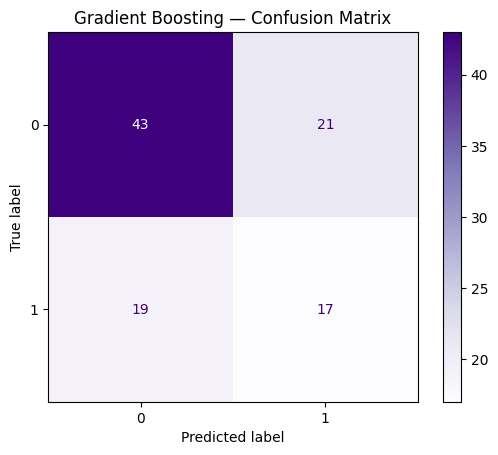

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(x_train_sm, y_train_sm)
y_pred_gb = gb.predict(x_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print('Gradient Boosting Accuracy:', acc_gb)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_gb))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb)).plot(cmap='Purples')
plt.title('Gradient Boosting — Confusion Matrix')
plt.show()

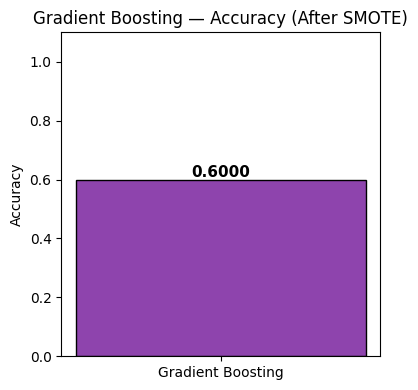

In [41]:
plt.figure(figsize=(4,4))
plt.bar(['Gradient Boosting'], [acc_gb], color='#8e44ad', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_gb]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('Gradient Boosting — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


### XGBoost

XGBoost Accuracy: 0.59
Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.69      0.66      0.67        64
           1       0.44      0.47      0.45        36

    accuracy                           0.59       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.60      0.59      0.59       100



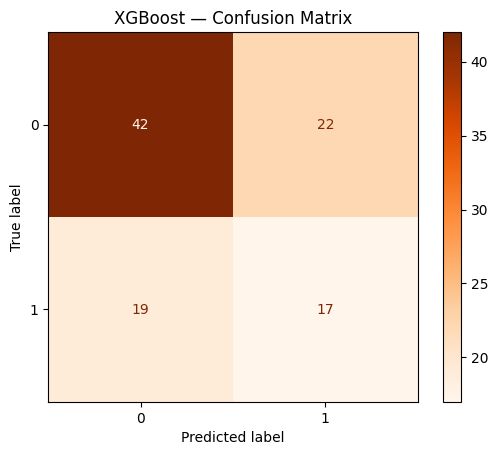

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(x_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(x_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print('XGBoost Accuracy:', acc_xgb)
print('Classification Report (Balanced):\n', classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot(cmap='Oranges')
plt.title('XGBoost — Confusion Matrix')
plt.show()


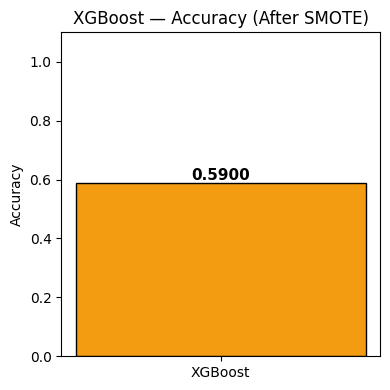

In [43]:
plt.figure(figsize=(4,4))
plt.bar(['XGBoost'], [acc_xgb], color='#f39c12', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
for i, v in enumerate([acc_xgb]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.title('XGBoost — Accuracy (After SMOTE)')
plt.tight_layout()
plt.show()


### After SMOTE — All Models Summary Plot

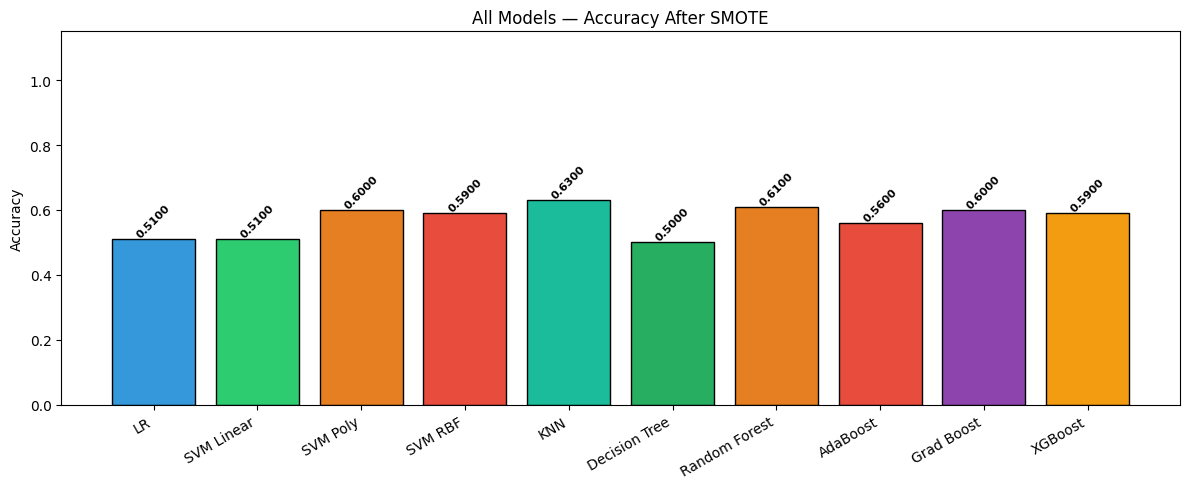

In [44]:
after_smote_models = ['LR','SVM Linear','SVM Poly','SVM RBF','KNN','Decision Tree','Random Forest','AdaBoost','Grad Boost','XGBoost']
after_smote_accs   = [acc_lr_after, acc_linear_after, acc_poly_after, acc_rbf_after, acc_knn, acc_dt, acc_rf, acc_ada, acc_gb, acc_xgb]
colors_after = ['#3498db','#2ecc71','#e67e22','#e74c3c','#1abc9c','#27ae60','#e67e22','#e74c3c','#8e44ad','#f39c12']
plt.figure(figsize=(12,5))
bars = plt.bar(after_smote_models, after_smote_accs, color=colors_after, edgecolor='black')
for bar, acc in zip(bars, after_smote_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{acc:.4f}', ha='center', fontsize=8, fontweight='bold', rotation=45)
plt.ylim(0, 1.15)
plt.ylabel('Accuracy')
plt.title('All Models — Accuracy After SMOTE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Before vs After SMOTE — Full Comparison (LR + SVM Kernels)

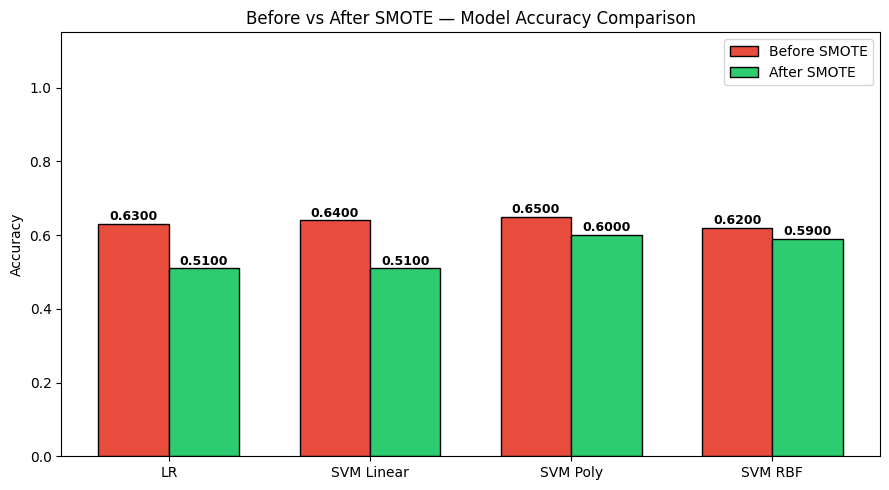

In [45]:
compare_labels = ['LR', 'SVM Linear', 'SVM Poly', 'SVM RBF']
before_compare = [acc_lr_before, acc_linear_before, acc_poly_before, acc_rbf_before]
after_compare  = [acc_lr_after,  acc_linear_after,  acc_poly_after,  acc_rbf_after]
x_pos2 = np.arange(len(compare_labels))
width2 = 0.35
fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x_pos2 - width2/2, before_compare, width2, label='Before SMOTE', color='#e74c3c', edgecolor='black')
b2 = ax.bar(x_pos2 + width2/2, after_compare,  width2, label='After SMOTE',  color='#2ecc71', edgecolor='black')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x_pos2)
ax.set_xticklabels(compare_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Before vs After SMOTE — Model Accuracy Comparison')
ax.legend()
plt.tight_layout()
plt.show()


---
## PCA — Before & After

### Before PCA — Boosting & Bagging Results (already above)
### After PCA — Apply PCA then run RF, AdaBoost, GBoost, XGBoost

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42) # Keep 95% variance
x_train_pca = pca.fit_transform(x_train_sm)
x_test_pca = pca.transform(x_test)

print('Original features:', x_train_sm.shape[1])
print('After PCA features:', x_train_pca.shape[1])

Original features: 12
After PCA features: 11


Random Forest (PCA) Accuracy: 0.64
              precision    recall  f1-score   support

           0       0.69      0.78      0.74        64
           1       0.50      0.39      0.44        36

    accuracy                           0.64       100
   macro avg       0.60      0.59      0.59       100
weighted avg       0.62      0.64      0.63       100



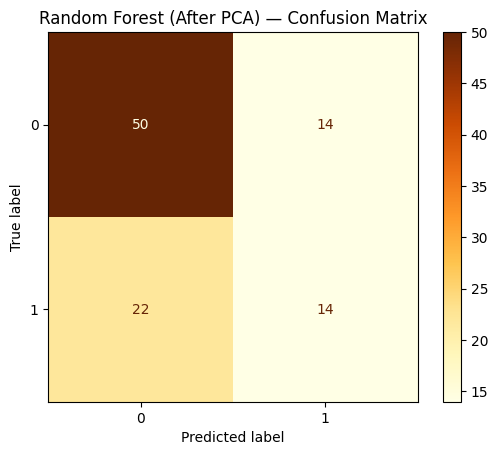

AdaBoost (PCA) Accuracy: 0.59
              precision    recall  f1-score   support

           0       0.69      0.66      0.67        64
           1       0.44      0.47      0.45        36

    accuracy                           0.59       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.60      0.59      0.59       100



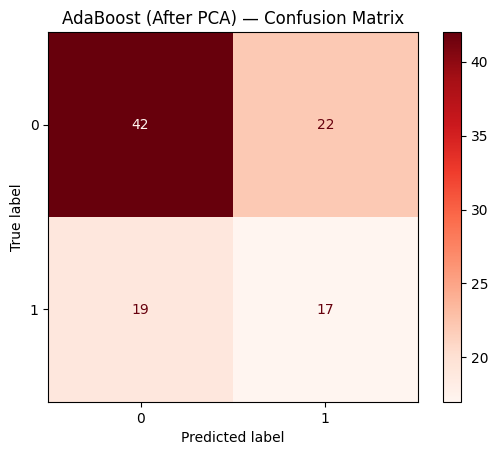

GradientBoost (PCA) Accuracy: 0.7
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        64
           1       0.59      0.53      0.56        36

    accuracy                           0.70       100
   macro avg       0.67      0.66      0.67       100
weighted avg       0.69      0.70      0.70       100



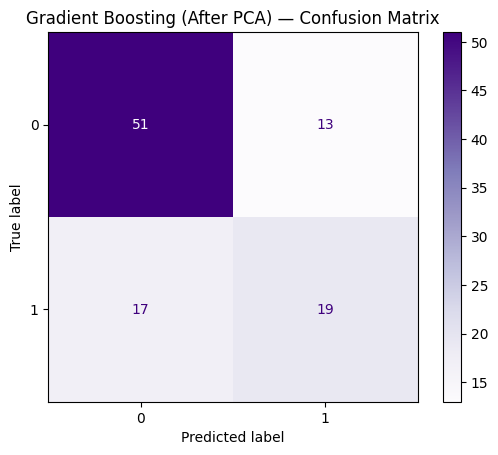

XGBoost (PCA) Accuracy: 0.64
              precision    recall  f1-score   support

           0       0.70      0.77      0.73        64
           1       0.50      0.42      0.45        36

    accuracy                           0.64       100
   macro avg       0.60      0.59      0.59       100
weighted avg       0.63      0.64      0.63       100



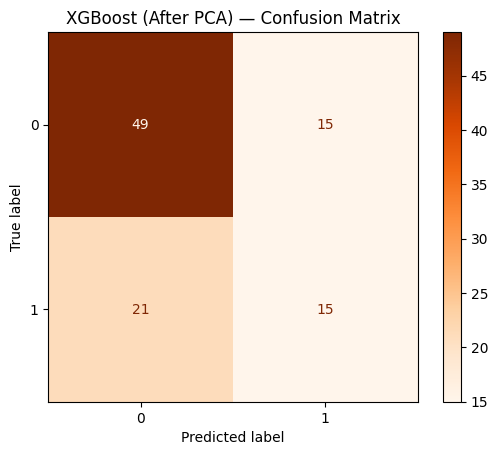

In [47]:
# Random Forest AFTER PCA
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(x_train_pca, y_train_sm)
y_pred_rf_pca = rf_pca.predict(x_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)
print('Random Forest (PCA) Accuracy:', acc_rf_pca)
print(classification_report(y_test, y_pred_rf_pca))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf_pca)).plot(cmap='YlOrBr')
plt.title('Random Forest (After PCA) — Confusion Matrix')
plt.show()

# AdaBoost AFTER PCA
ada_pca = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_pca.fit(x_train_pca, y_train_sm)
y_pred_ada_pca = ada_pca.predict(x_test_pca)
acc_ada_pca = accuracy_score(y_test, y_pred_ada_pca)
print('AdaBoost (PCA) Accuracy:', acc_ada_pca)
print(classification_report(y_test, y_pred_ada_pca))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ada_pca)).plot(cmap='Reds')
plt.title('AdaBoost (After PCA) — Confusion Matrix')
plt.show()

# GBoost AFTER PCA
gb_pca = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_pca.fit(x_train_pca, y_train_sm)
y_pred_gb_pca = gb_pca.predict(x_test_pca)
acc_gb_pca = accuracy_score(y_test, y_pred_gb_pca)
print('GradientBoost (PCA) Accuracy:', acc_gb_pca)
print(classification_report(y_test, y_pred_gb_pca))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb_pca)).plot(cmap='Purples')
plt.title('Gradient Boosting (After PCA) — Confusion Matrix')
plt.show()

# XGBoost AFTER PCA
xgb_pca = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_pca.fit(x_train_pca, y_train_sm)
y_pred_xgb_pca = xgb_pca.predict(x_test_pca)
acc_xgb_pca = accuracy_score(y_test, y_pred_xgb_pca)
print('XGBoost (PCA) Accuracy:', acc_xgb_pca)
print(classification_report(y_test, y_pred_xgb_pca))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb_pca)).plot(cmap='Oranges')
plt.title('XGBoost (After PCA) — Confusion Matrix')
plt.show()

---
## Before PCA vs After PCA — Bagging & Boosting Comparison

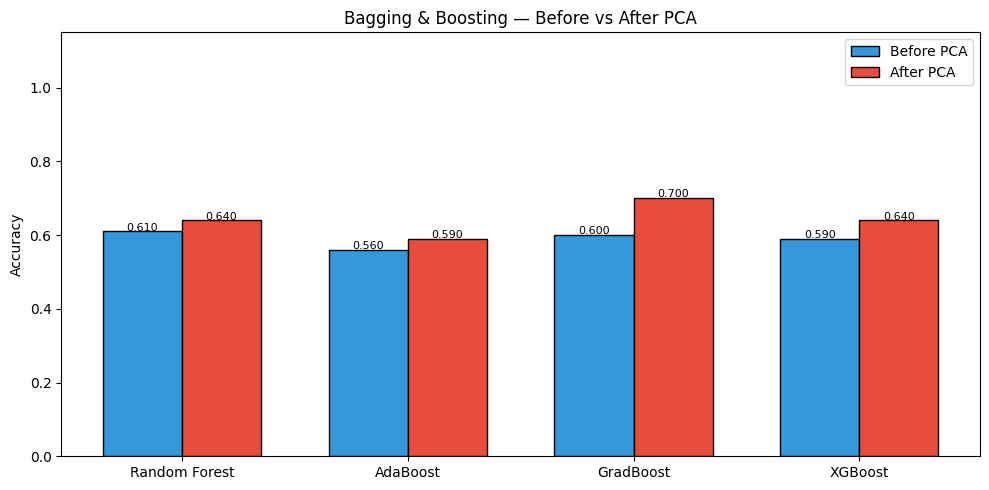

In [48]:
model_names = ['Random Forest','AdaBoost','GradBoost','XGBoost']
before_pca_accs = [acc_rf, acc_ada, acc_gb, acc_xgb]
after_pca_accs = [acc_rf_pca, acc_ada_pca, acc_gb_pca, acc_xgb_pca]

x_pos = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x_pos - width/2, before_pca_accs, width, label='Before PCA', color='#3498db', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, after_pca_accs, width, label='After PCA', color='#e74c3c', edgecolor='black')
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Bagging & Boosting — Before vs After PCA')
ax.legend()
plt.tight_layout()
plt.show()


---
## Final Comparison — ALL Models

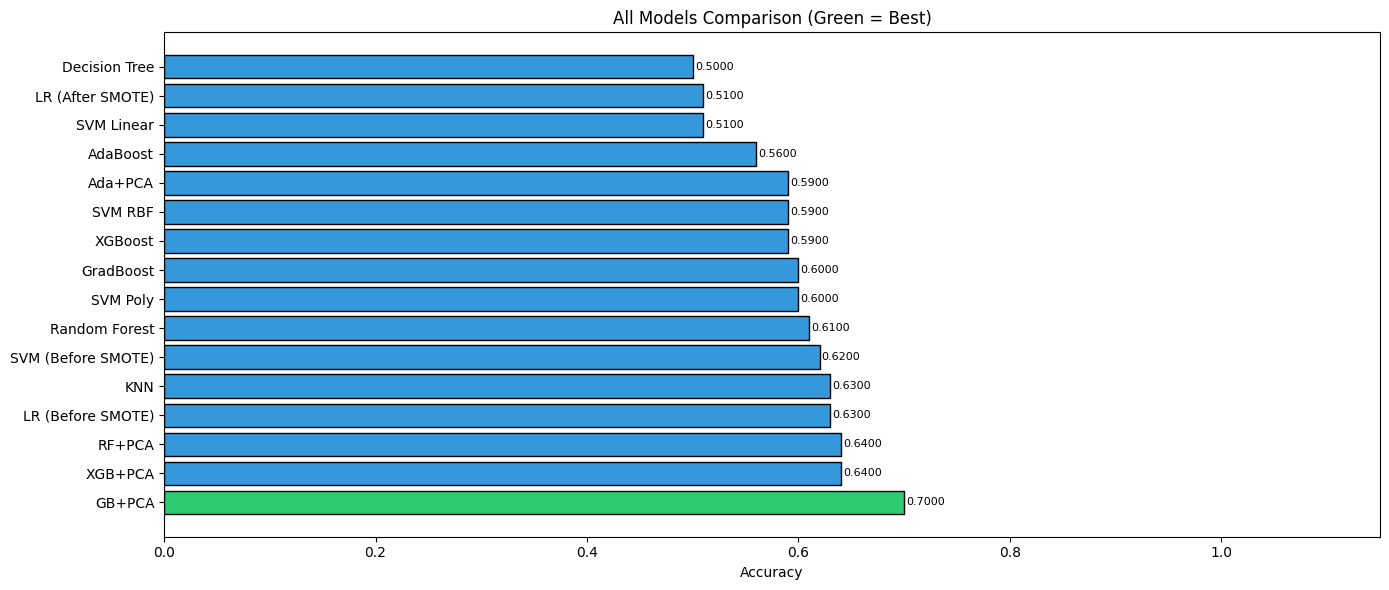


BEST MODEL: GB+PCA with Accuracy = 0.7000


In [49]:
all_models = [
    'LR (Before SMOTE)', 'SVM (Before SMOTE)',
    'LR (After SMOTE)', 'SVM Linear', 'SVM Poly', 'SVM RBF',
    'KNN', 'Decision Tree',
    'Random Forest', 'AdaBoost', 'GradBoost', 'XGBoost',
    'RF+PCA', 'Ada+PCA', 'GB+PCA', 'XGB+PCA'
]
all_accs = [
    acc_lr_before, acc_svm_before,
    acc_lr_after, acc_linear_after, acc_poly_after, acc_rbf_after,
    acc_knn, acc_dt,
    acc_rf, acc_ada, acc_gb, acc_xgb,
    acc_rf_pca, acc_ada_pca, acc_gb_pca, acc_xgb_pca
]

sorted_pairs = sorted(zip(all_accs, all_models), reverse=True)
sorted_accs, sorted_names = zip(*sorted_pairs)

colors = ['#2ecc71' if a == max(all_accs) else '#3498db' for a in sorted_accs]

plt.figure(figsize=(14,6))
bars = plt.barh(sorted_names, sorted_accs, color=colors, edgecolor='black')
for bar, acc in zip(bars, sorted_accs):
    plt.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{acc:.4f}', va='center', fontsize=8)
plt.xlim(0, 1.15)
plt.xlabel('Accuracy')
plt.title('All Models Comparison (Green = Best)')
plt.tight_layout()
plt.show()

best_model = sorted_names[0]
best_acc_val = sorted_accs[0]
print(f'\nBEST MODEL: {best_model} with Accuracy = {best_acc_val:.4f}')
